# Análise Financeira da Prefeitura Municipal de Teixeira (PB)

**Fonte:** despesas empenhadas, liquidadas e pagas pela Prefeitura de Teixeira/PB, 2014–2024 (Portal da Transparência / TCE-PB).

**Objetivo:** aplicar boas práticas de limpeza de dados e de visualização (ver `README.md` do curso *Visualização de Dados* – percepção visual, cores, formas de representação e *storytelling*) para:

1. Diagnosticar e tratar problemas de qualidade nos dados brutos;
2. Entender a evolução do gasto público ao longo de 11 anos;
3. Explorar a composição do orçamento (funções, fornecedores, execução orçamentária);
4. Levantar **indícios** (não conclusões) de padrões atípicos que mereçam investigação mais aprofundada — concentração de fornecedores, ausência de licitação, Lei de Benford, possível fracionamento de despesas.

> ⚠️ Este notebook identifica *sinais estatísticos*, não provas de irregularidade. Qualquer achado aqui deve ser cruzado com os processos administrativos e documentos originais antes de qualquer conclusão.

In [1]:
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

# --- paleta validada (skill de dataviz): ordem categórica fixa, nunca ciclada ---
CAT_PALETTE = {
    "blue": "#2a78d6",
    "aqua": "#1baf7a",
    "yellow": "#eda100",
    "green": "#008300",
    "violet": "#4a3aa7",
    "red": "#e34948",
    "magenta": "#e87ba4",
    "orange": "#eb6834",
}
CAT_ORDER = list(CAT_PALETTE.values())

STATUS = {
    "good": "#0ca30c",
    "warning": "#fab219",
    "serious": "#ec835a",
    "critical": "#d03b3b",
}

INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRID = "#e1e0d9"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK_SECONDARY,
    "axes.titlecolor": INK,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "text.color": INK,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "font.family": "sans-serif",
    "font.size": 10.5,
    "figure.dpi": 100,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def fmt_reais(valor, pos=None):
    """Formata em R$ com separador de milhar; usado em rótulos diretos (não em eixos densos)."""
    if abs(valor) >= 1_000_000:
        return f"R$ {valor/1_000_000:,.1f} mi".replace(",", "@").replace(".", ",").replace("@", ".")
    if abs(valor) >= 1_000:
        return f"R$ {valor/1_000:,.0f} mil".replace(",", ".")
    return f"R$ {valor:,.0f}".replace(",", ".")


def fmt_reais_full(valor):
    """Formata em R$ com centavos, formato brasileiro completo."""
    s = f"{valor:,.2f}"
    s = s.replace(",", "@").replace(".", ",").replace("@", ".")
    return f"R$ {s}"


def fmt_valor_eixo(valor, pos=None):
    """Formata sem o prefixo 'R$' (que fica só no rótulo do eixo) — evita ticks longos e sobrepostos."""
    if abs(valor) >= 1_000_000:
        return f"{valor/1_000_000:,.1f} mi".replace(",", "@").replace(".", ",").replace("@", ".")
    if abs(valor) >= 1_000:
        return f"{valor/1_000:,.0f} mil".replace(",", ".")
    return f"{valor:,.0f}".replace(",", ".")


REAIS_AXIS = mticker.FuncFormatter(fmt_reais)
EIXO_VALOR = mticker.FuncFormatter(fmt_valor_eixo)  # usar em eixos com muitos ticks; some com "R$" no eixo/label
ANOS_ELEICAO_MUNICIPAL = [2016, 2020, 2024]


## 1. Carga dos dados e diagnóstico inicial

O arquivo é exportado do sistema contábil em `;` como separador, `utf-8-sig` como codificação e números no formato brasileiro (`1.234,56`). Cada linha é um empenho (`DL`) com seus valores fixado/empenhado/liquidado/pago/anulado.

In [2]:
CAMINHO_DADOS = "dados/dados_processados_teixeira.csv"

raw = pd.read_csv(CAMINHO_DADOS, sep=";", encoding="utf-8-sig", low_memory=False, dtype=str)

print(f"Linhas: {raw.shape[0]:,}".replace(",", "."), f"| Colunas: {raw.shape[1]}")
print()
print("Nulos por coluna (top 10):")
print(raw.isna().sum().sort_values(ascending=False).head(10))
print()
print("Marcador de tipo de registro (1ª coluna):")
print(raw["Unnamed: 0"].value_counts().head(3))

Linhas: 86.895 | Colunas: 29

Nulos por coluna (top 10):
Valor Anulado          86664
Data de Liquidação     77140
Nº Licitação           71540
 Data de Liquidação    10748
Data de Pagamento       4860
 Valor Saldo             462
Valor Pago               286
Valor Empenhado          281
Natureza                 280
Valor Liquidado          280
dtype: int64

Marcador de tipo de registro (1ª coluna):
Unnamed: 0
DL     86745
          67
)         35
Name: count, dtype: int64


## 2. Limpeza e tratamento dos dados

### 2.1 Linhas corrompidas por quebra de linha no campo `Histórico`

A primeira coluna (`Unnamed: 0`) deveria ser sempre `"DL"`. Cerca de 150 linhas têm ali um pedaço de texto solto — sinal de que o campo `Histórico` de algum registro continha uma quebra de linha literal, fazendo o exportador do sistema contábil dividir **um único empenho em duas linhas físicas do CSV**. A segunda "linha" nasce deslocada 7 colunas para a esquerda.

Estratégia:
- Quando o deslocamento é simples (1 fragmento após o registro truncado), reconstruímos o registro: concatenamos o texto no `Histórico` e realocamos os valores para as colunas certas.
- Quando há múltiplas quebras encadeadas (registro corrompido mais de uma vez), o realinhamento é ambíguo — descartamos essas poucas linhas para não injetar dado errado.

In [3]:
df = raw.copy()
cols = list(df.columns)
n_cols = len(cols)

is_frag = df["Unnamed: 0"] != "DL"
frag_idx = list(df.index[is_frag])

# agrupa fragmentos consecutivos (registros com mais de uma quebra encadeada)
chains, cur = [], []
for i in frag_idx:
    if cur and i == cur[-1] + 1:
        cur.append(i)
    else:
        if cur:
            chains.append(cur)
        cur = [i]
if cur:
    chains.append(cur)

SHIFT = 7  # deslocamento observado empiricamente entre o fragmento e o esquema real
to_drop, repaired, dropped_ambiguous = [], 0, 0

for chain in chains:
    anchor = chain[0] - 1
    if anchor not in df.index or df.at[anchor, "Unnamed: 0"] != "DL":
        to_drop.extend(chain)
        dropped_ambiguous += len(chain)
        continue
    if len(chain) == 1:
        frag = df.loc[chain[0]]
        df.at[anchor, "Histórico"] = f"{df.at[anchor, 'Histórico']} {frag[cols[0]]}".strip()
        for j in range(1, n_cols):
            target = j + SHIFT
            if target >= n_cols:
                break
            if pd.isna(df.at[anchor, cols[target]]):
                df.at[anchor, cols[target]] = frag[cols[j]]
        to_drop.append(chain[0])
        repaired += 1
    else:
        to_drop.append(anchor)
        to_drop.extend(chain)
        dropped_ambiguous += len(chain) + 1

df = df.drop(index=to_drop).reset_index(drop=True)
assert (df["Unnamed: 0"] == "DL").all()
df = df.drop(columns=["Unnamed: 0"])

print(f"Registros reconstruídos automaticamente: {repaired}")
print(f"Registros descartados por corrupção ambígua: {dropped_ambiguous}")
print(f"Shape após tratamento: {df.shape}")

Registros reconstruídos automaticamente: 130
Registros descartados por corrupção ambígua: 26
Shape após tratamento: (86739, 28)


### 2.2 Colunas duplicadas, datas e valores monetários

O cabeçalho traz **duas colunas chamadas `Data de Liquidação`** (uma com espaço em branco no nome). Conferimos que elas nunca vêm preenchidas ao mesmo tempo na mesma linha — ou seja, é o mesmo campo lógico partido em dois por um problema de exportação — e as unificamos.

Em seguida: `Data`, `Data de Pagamento` e `Data de Liquidação` viram `datetime`; os campos de valor (`Valor Fixado/Empenhado/Liquidado/Pago/Anulado/Saldo`) saem do formato brasileiro (`1.234,56`) para `float`.

In [4]:
# coalesce das duas colunas "Data de Liquidação" (nunca preenchidas simultaneamente)
liq_a, liq_b = df[" Data de Liquidação"], df["Data de Liquidação"]
overlap = (liq_a.notna() & liq_b.notna()).sum()
print(f"Linhas com as duas colunas preenchidas ao mesmo tempo: {overlap}")

df["_data_liquidacao"] = liq_a.fillna(liq_b)
df = df.drop(columns=[" Data de Liquidação", "Data de Liquidação"]).rename(
    columns={"_data_liquidacao": "Data de Liquidação"}
)
df.columns = [c.strip() for c in df.columns]

# datas
for c in ["Data", "Data de Pagamento", "Data de Liquidação"]:
    df[c] = pd.to_datetime(df[c], format="%d/%m/%Y", errors="coerce")


def to_num(serie):
    return pd.to_numeric(
        serie.astype(str).str.strip().replace({"": np.nan, "nan": np.nan})
        .str.replace(".", "", regex=False).str.replace(",", ".", regex=False),
        errors="coerce",
    )


VALOR_COLS = ["Valor Fixado", "Valor Empenhado", "Valor Liquidado", "Valor Pago", "Valor Anulado", "Valor Saldo"]
for c in VALOR_COLS:
    df[c] = to_num(df[c])

print(f"Período coberto: {df['Data'].min():%d/%m/%Y} a {df['Data'].max():%d/%m/%Y}")
print(f"Datas não interpretáveis: {df['Data'].isna().sum()}")
df[VALOR_COLS].describe().round(2)

Linhas com as duas colunas preenchidas ao mesmo tempo: 5


Período coberto: 02/01/2014 a 22/11/2024
Datas não interpretáveis: 0


,Valor Fixado,Valor Empenhado,Valor Liquidado,Valor Pago,Valor Anulado,Valor Saldo
count,86502.00,86678.00,86734.00,86736.00,235.00,86561.00
mean,168585.74,5309.22,5167.53,4946.57,7710.23,217.81
std,302523.77,23101.89,22272.91,21792.17,25831.83,4746.84
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,20000.00,200.00,191.20,150.00,150.00,0.00
50%,80000.00,954.00,944.00,864.00,1361.40,0.00
75%,206516.00,2348.17,2318.00,2199.46,7418.40,0.00
max,5100000.00,916884.41,916884.41,916884.41,279575.00,425682.00


### 2.3 Engenharia de atributos

Campos como `Órgão`, `Função`, `Elemento` etc. vêm no formato `"código - descrição"`. Extraímos a descrição para os campos que usaremos nos gráficos e normalizamos a caixa do texto (o sistema mistura `"DESPESAS CORRENTES"` e `"Despesas Correntes"` como se fossem categorias diferentes). Também derivamos `Ano`/`Mês` e o indicador de execução (`% pago do empenhado`).

Observação sobre `Órgão`: quase 100% dos registros pertencem a uma única entidade (a própria Prefeitura), então essa coluna não ajuda a segmentar o gasto — usamos `Unid. Orc` (a secretaria/fundo responsável) para isso.

In [5]:
def split_code_desc(serie, upper=False):
    """'8 - Assistência Social' -> 'Assistência Social' (ou a própria string se não houver ' - ')."""
    partes = serie.astype(str).str.split(" - ", n=1, expand=True)
    desc = partes[1] if partes.shape[1] > 1 else pd.Series(np.nan, index=serie.index)
    resultado = desc.fillna(serie).str.strip()
    return resultado.str.upper() if upper else resultado


df["ano"] = df["Data"].dt.year
df["mes"] = df["Data"].dt.month
df["funcao"] = split_code_desc(df["Função"])
df["unidade"] = split_code_desc(df["Unid. Orc"])
df["categoria_economica"] = split_code_desc(df["Categoria Econômica"], upper=True)
df["elemento"] = split_code_desc(df["Elemento"], upper=True)

df["pct_execucao"] = np.where(df["Valor Empenhado"] > 0, df["Valor Pago"] / df["Valor Empenhado"], np.nan)

# entidades que representam transferências internas/estatutárias, não "fornecedores" de mercado
ENTIDADES_INTERNAS = ["Prefeitura Municipal de Teixeira", "INSS", "RECEITA FEDERAL"]

print("Funções (top 10):")
print(df["funcao"].value_counts().head(10))
print()
print("Categoria econômica (normalizada):")
print(df["categoria_economica"].value_counts().head(5))

Funções (top 10):
funcao
Saúde                    21282
Educação                 18966
Assistência Social       15739
Administração            14594
Urbanismo                 5632
Agricultura               2991
Encargos Especiais        2137
Direitos da Cidadania     1799
Comunicação               1671
Gestão Ambiental           731
Name: count, dtype: int64

Categoria econômica (normalizada):
categoria_economica
DESPESAS CORRENTES                                                                                          85150
DESPESAS DE CAPITAL                                                                                          1352
IMPLEMENTAR NOVO MODELO DE GESTÃO NA SAÚDE                                                                     54
MANUTENÇÃO DAS ATIVIDADES DAS AÇÕES E SERVIÇOS PÚBLICOS DE SAÚDE - BLOCO ATENÇÃO ESPECIALIZADA-MAC - SUS       47
MANUTENÇÃO DA UNIDADE MISTA SANCHO LEITE-RECURSOS PRÓPRIOS                                                     28
Name: count, 

## 3. Visão geral

Com os dados tratados, um retrato rápido do que temos em mãos antes de entrar nos gráficos.

In [6]:
total_empenhado = df["Valor Empenhado"].sum()
total_pago = df["Valor Pago"].sum()
n_empenhos = len(df)
n_fornecedores = df["Nome"].nunique()
ticket_medio = df["Valor Empenhado"].mean()

kpis = pd.Series({
    "Período": f"{df['ano'].min()}–{df['ano'].max()}",
    "Nº de empenhos": f"{n_empenhos:,}".replace(",", "."),
    "Total empenhado": fmt_reais_full(total_empenhado),
    "Total pago": fmt_reais_full(total_pago),
    "Execução geral (pago/empenhado)": f"{total_pago/total_empenhado:.1%}",
    "Fornecedores/beneficiários únicos": f"{n_fornecedores:,}".replace(",", "."),
    "Ticket médio por empenho": fmt_reais_full(ticket_medio),
    "% dos empenhos sem licitação": f"{(df['Licitação']=='NÃO').mean():.1%}",
})
kpis.to_frame("valor")

,valor
Período,2014–2024
Nº de empenhos,86.739
Total empenhado,"R$ 460.192.337,25"
Total pago,"R$ 429.045.494,03"
Execução geral (pago/empenhado),93.2%
Fornecedores/beneficiários únicos,7.568
Ticket médio por empenho,"R$ 5.309,22"
% dos empenhos sem licitação,82.5%


## 4. Evolução temporal do gasto

### 4.1 Gasto anual: Empenhado × Liquidado × Pago

Três estágios da despesa pública, do mesmo `Ano`. Como as três séries têm a mesma unidade e ordem natural (Pago ≤ Liquidado ≤ Empenhado), usamos uma única escala (nunca eixo duplo) e destacamos os anos de eleição municipal (2016, 2020, 2024) para checar se há aceleração de gasto em ano eleitoral.

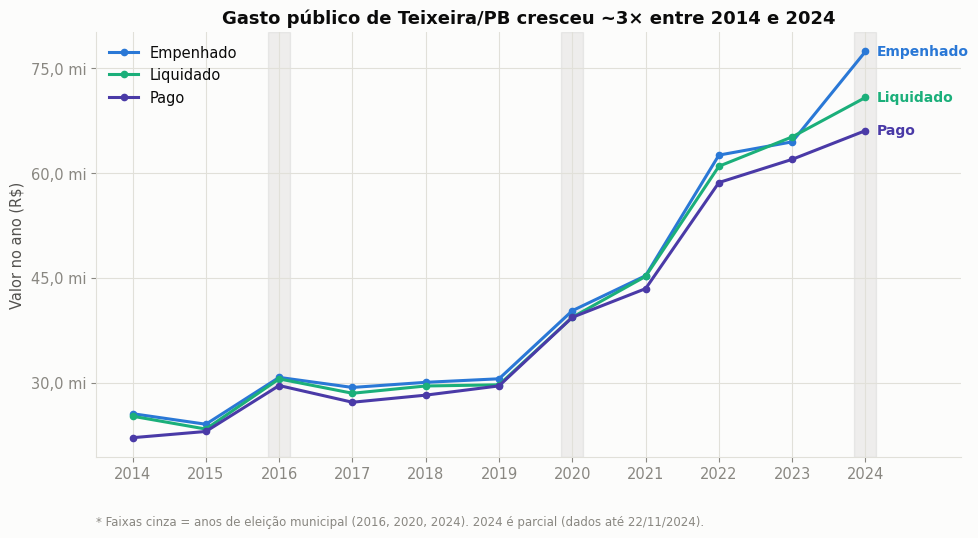

Variação anual do valor empenhado:
ano
2015    -5.9%
2016    27.8%
2017    -4.7%
2018     2.5%
2019     1.7%
2020    31.9%
2021    12.4%
2022    38.1%
2023     3.0%
2024    20.1%
Name: Valor Empenhado, dtype: object


In [7]:
anual = df.groupby("ano")[["Valor Empenhado", "Valor Liquidado", "Valor Pago"]].sum()

SERIES_COLOR = {"Valor Empenhado": CAT_PALETTE["blue"], "Valor Liquidado": CAT_PALETTE["aqua"], "Valor Pago": CAT_PALETTE["violet"]}
SERIES_LABEL = {"Valor Empenhado": "Empenhado", "Valor Liquidado": "Liquidado", "Valor Pago": "Pago"}

fig, ax = plt.subplots(figsize=(10, 5.5))
for col in ["Valor Empenhado", "Valor Liquidado", "Valor Pago"]:
    ax.plot(anual.index, anual[col], color=SERIES_COLOR[col], linewidth=2.2, marker="o", markersize=4.5, label=SERIES_LABEL[col])
    ax.annotate(SERIES_LABEL[col], (anual.index[-1], anual[col].iloc[-1]), xytext=(8, 0),
                textcoords="offset points", color=SERIES_COLOR[col], fontweight="bold", va="center", fontsize=10)

for ano_e in ANOS_ELEICAO_MUNICIPAL:
    if ano_e in anual.index:
        ax.axvspan(ano_e - 0.15, ano_e + 0.15, color=INK_MUTED, alpha=0.12, zorder=0)

ax.yaxis.set_major_formatter(EIXO_VALOR)
ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=6))
ax.set_xticks(anual.index)
ax.set_xticklabels(anual.index, rotation=0)
ax.set_xlim(anual.index.min() - 0.5, anual.index.max() + 1.3)
ax.set_title("Gasto público de Teixeira/PB cresceu ~3× entre 2014 e 2024")
ax.set_xlabel("")
ax.set_ylabel("Valor no ano (R$)")
ax.text(0, -0.16, "* Faixas cinza = anos de eleição municipal (2016, 2020, 2024). 2024 é parcial (dados até 22/11/2024).",
        transform=ax.transAxes, fontsize=8.5, color=INK_MUTED)
ax.legend(loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

variacao = anual["Valor Empenhado"].pct_change().dropna()
print("Variação anual do valor empenhado:")
print((variacao * 100).round(1).astype(str) + "%")

### 4.2 Sazonalidade: em que meses o gasto se concentra?

Uma grade Ano × Mês pede um **heatmap sequencial** (magnitude, um único tom do azul-referência, mais escuro = mais gasto).

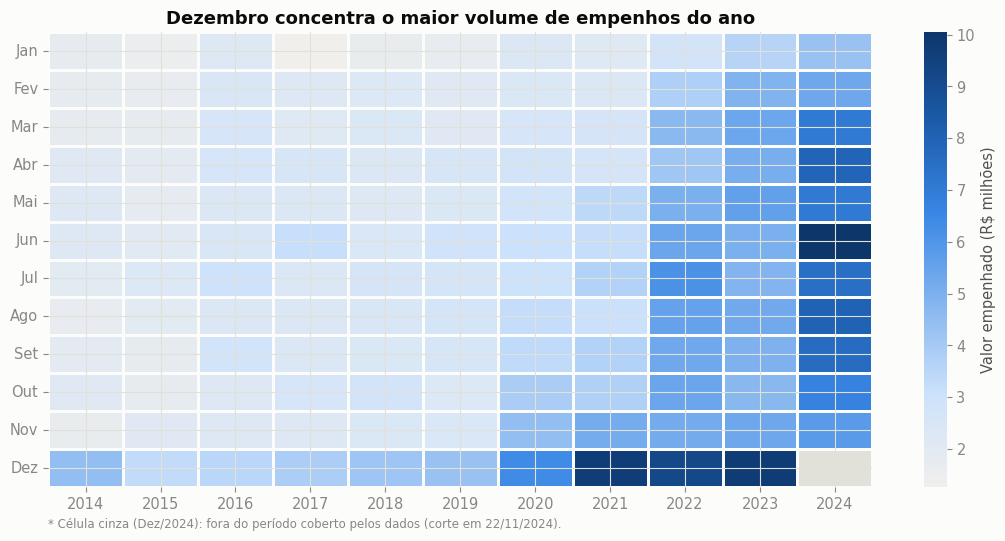

In [8]:
from matplotlib.colors import LinearSegmentedColormap

BLUE_SEQ = LinearSegmentedColormap.from_list(
    "blue_seq", ["#f0efec", "#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]
)
BLUE_SEQ.set_bad(color="#e1e0d9")

pivot = df.pivot_table(index="mes", columns="ano", values="Valor Empenhado", aggfunc="sum", fill_value=0)
pivot.loc[12, 2024] = np.nan  # dezembro/2024 ainda não ocorreu nos dados (corte em 22/11/2024)
meses_nomes = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"]

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.heatmap(
    pivot / 1_000_000, cmap=BLUE_SEQ, linewidths=2, linecolor=SURFACE, ax=ax,
    cbar_kws={"label": "Valor empenhado (R$ milhões)"},
)
ax.set_yticklabels(meses_nomes, rotation=0)
ax.set_title("Dezembro concentra o maior volume de empenhos do ano")
ax.set_xlabel("")
ax.set_ylabel("")
ax.text(0, -0.09, "* Célula cinza (Dez/2024): fora do período coberto pelos dados (corte em 22/11/2024).",
        transform=ax.transAxes, fontsize=8.5, color=INK_MUTED)
plt.tight_layout()
plt.show()

## 5. Composição do gasto

### 5.1 Para onde vai o dinheiro: funções de governo

Ranking de magnitude → barras horizontais, ordenadas, um único tom (sequencial).

Registros com Função ilegível excluídos deste gráfico: 237 (R$ 14,6 mi)


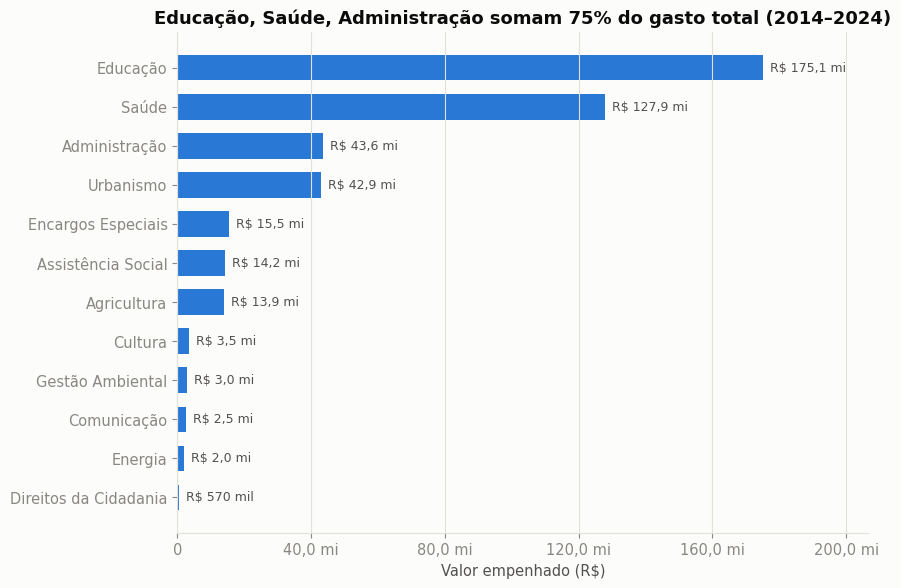

Nota: por número de lançamentos, Assistência Social é a 3ª maior função (muitos auxílios de baixo valor);
por valor total, ela cai para a 6ª posição — Administração assume o 3º lugar em valor.


In [9]:
# uma fração residual de linhas (~0,3% do valor total) tem, no campo Função, texto de
# outra coluna (nome de secretaria/fundo) — resíduo de corrupção não coberto pelo reparo da seção 2.1.
# Não são categorias de função válidas, então são excluídas apenas desta visão.
funcao_invalida = df["funcao"].str.contains(
    "Secretaria|Fundo|Prefeitura|Ordinário|Poder Executivo|Fundeb|FUTURISTA", case=False, na=False
)
print(f"Registros com Função ilegível excluídos deste gráfico: {funcao_invalida.sum()} "
      f"({fmt_reais(df.loc[funcao_invalida, 'Valor Empenhado'].sum())})")

por_funcao = (
    df.loc[~funcao_invalida].groupby("funcao")["Valor Empenhado"].sum()
    .sort_values(ascending=False).head(12).sort_values(ascending=True)
)
top3_nomes = ", ".join(por_funcao.sort_values(ascending=False).head(3).index)
top3_share = por_funcao.sort_values(ascending=False).head(3).sum() / df["Valor Empenhado"].sum()

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(por_funcao.index, por_funcao.values, color=CAT_PALETTE["blue"], height=0.65)
for bar, val in zip(bars, por_funcao.values):
    ax.text(val + por_funcao.max() * 0.012, bar.get_y() + bar.get_height() / 2, fmt_reais(val),
            va="center", fontsize=9, color=INK_SECONDARY)

ax.xaxis.set_major_formatter(EIXO_VALOR)
ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=6))
ax.set_xlim(0, por_funcao.max() * 1.18)
ax.set_xlabel("Valor empenhado (R$)")
ax.set_title(f"{top3_nomes} somam {top3_share:.0%} do gasto total (2014–2024)")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

print(f"Nota: por número de lançamentos, Assistência Social é a 3ª maior função (muitos auxílios de baixo valor);\n"
      f"por valor total, ela cai para a {(por_funcao.sort_values(ascending=False).index.get_loc('Assistência Social') + 1)}ª posição — Administração assume o 3º lugar em valor.")

### 5.2 Despesas Correntes × Capital — obras crescem em ano eleitoral?

Parte-todo ao longo do tempo → barras 100% empilhadas, 2 categorias (paleta categórica, cor sempre ligada à mesma categoria em todos os anos).

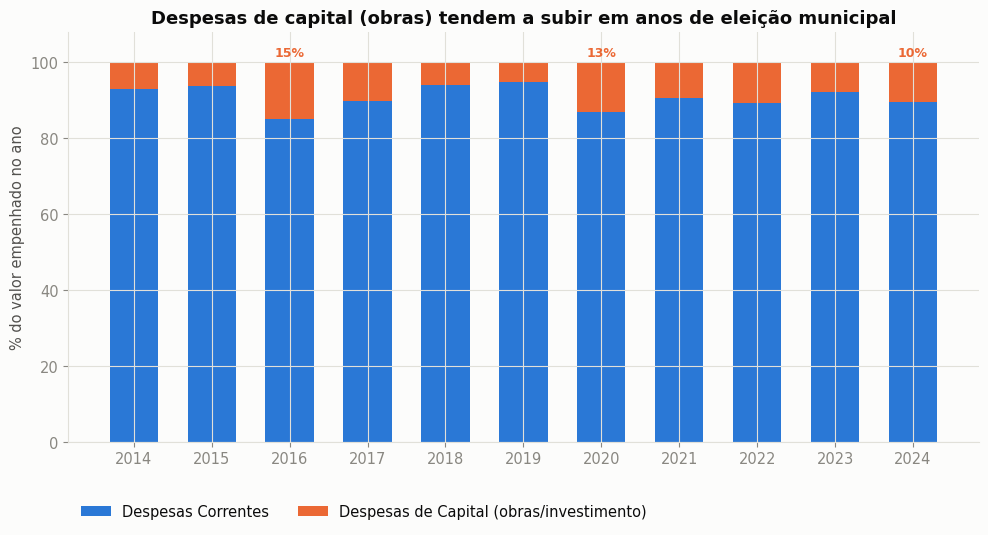

Média de despesas de capital em anos de eleição (2016/2020/2024): 12.8%
Média nos demais anos: 7.8%


In [10]:
pivot_cat = df.groupby(["ano", "categoria_economica"])["Valor Empenhado"].sum().unstack(fill_value=0)
pivot_cat = pivot_cat.reindex(columns=["DESPESAS CORRENTES", "DESPESAS DE CAPITAL"], fill_value=0)
pivot_pct = pivot_cat.div(pivot_cat.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5.5))
bottom = np.zeros(len(pivot_pct))
cores = [CAT_PALETTE["blue"], CAT_PALETTE["orange"]]
labels = ["Despesas Correntes", "Despesas de Capital (obras/investimento)"]
for cor, col, label in zip(cores, pivot_pct.columns, labels):
    ax.bar(pivot_pct.index, pivot_pct[col], bottom=bottom, color=cor, width=0.62, label=label)
    bottom += pivot_pct[col].values

for ano_e in ANOS_ELEICAO_MUNICIPAL:
    if ano_e in pivot_pct.index:
        ax.annotate(f"{pivot_pct.loc[ano_e, 'DESPESAS DE CAPITAL']:.0f}%", (ano_e, 100),
                    xytext=(0, 4), textcoords="offset points", ha="center", fontsize=9,
                    fontweight="bold", color=CAT_PALETTE["orange"])

media_eleicao = pivot_pct.loc[pivot_pct.index.isin(ANOS_ELEICAO_MUNICIPAL), "DESPESAS DE CAPITAL"].mean()
media_outros = pivot_pct.loc[~pivot_pct.index.isin(ANOS_ELEICAO_MUNICIPAL), "DESPESAS DE CAPITAL"].mean()

ax.set_ylim(0, 108)
ax.set_xticks(pivot_pct.index)
ax.set_ylabel("% do valor empenhado no ano")
ax.set_title("Despesas de capital (obras) tendem a subir em anos de eleição municipal")
ax.legend(loc="lower left", ncol=2, frameon=False, bbox_to_anchor=(0, -0.22))
plt.tight_layout()
plt.show()

print(f"Média de despesas de capital em anos de eleição (2016/2020/2024): {media_eleicao:.1f}%")
print(f"Média nos demais anos: {media_outros:.1f}%")

### 5.3 Top 10 elementos de despesa

Nível mais granular do plano de contas — mostra que a folha de pessoal (`Vencimentos`, `Contratação por Tempo Determinado`, `Obrigações Patronais`) domina sobre compras e serviços.

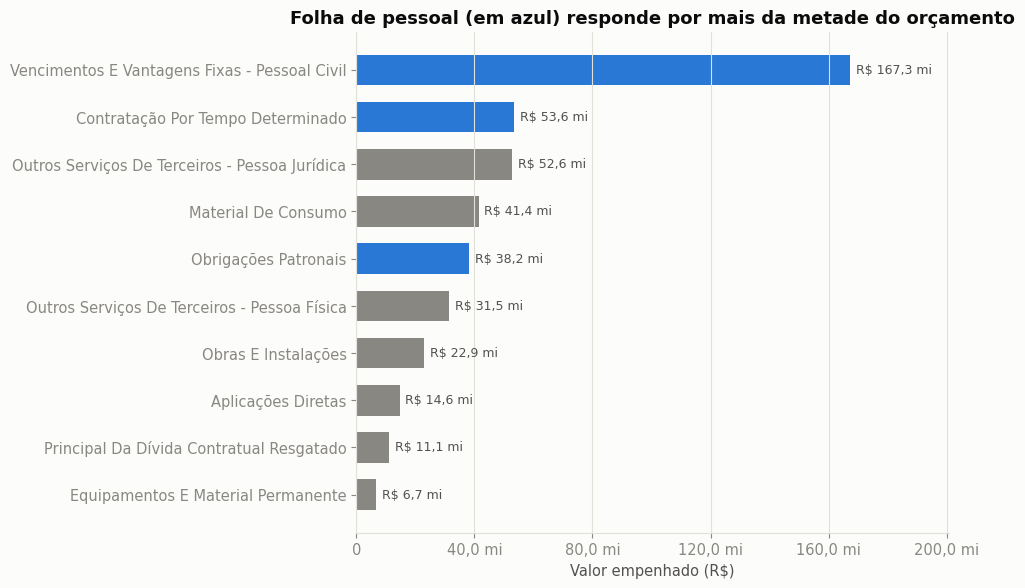

In [11]:
PESSOAL = {"VENCIMENTOS E VANTAGENS FIXAS - PESSOAL CIVIL", "CONTRATAÇÃO POR TEMPO DETERMINADO", "OBRIGAÇÕES PATRONAIS"}

top_elemento = df.groupby("elemento")["Valor Empenhado"].sum().sort_values(ascending=False).head(10).sort_values()
# forma "emphasis": o que importa (folha de pessoal) em destaque, o resto em cinza de contexto
cores_elem = [CAT_PALETTE["blue"] if e in PESSOAL else INK_MUTED for e in top_elemento.index]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh([e.title() for e in top_elemento.index], top_elemento.values, color=cores_elem, height=0.65)
for bar, val in zip(bars, top_elemento.values):
    ax.text(val + top_elemento.max() * 0.012, bar.get_y() + bar.get_height() / 2, fmt_reais(val),
            va="center", fontsize=9, color=INK_SECONDARY)

ax.xaxis.set_major_formatter(EIXO_VALOR)
ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=6))
ax.set_xlim(0, top_elemento.max() * 1.2)
ax.set_xlabel("Valor empenhado (R$)")
ax.set_title("Folha de pessoal (em azul) responde por mais da metade do orçamento")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

## 6. Fornecedores e concentração

### 6.1 Quem mais recebeu da Prefeitura?

Atenção: **"Prefeitura Municipal de Teixeira", INSS e Receita Federal** aparecem como os maiores "recebedores" porque o campo `Nome` também é usado para transferências internas (tarifas bancárias, restituições) e retenções estatutárias (INSS, IR) — não são fornecedores de mercado. Mostramos os dois recortes lado a lado para não distorcer a leitura.

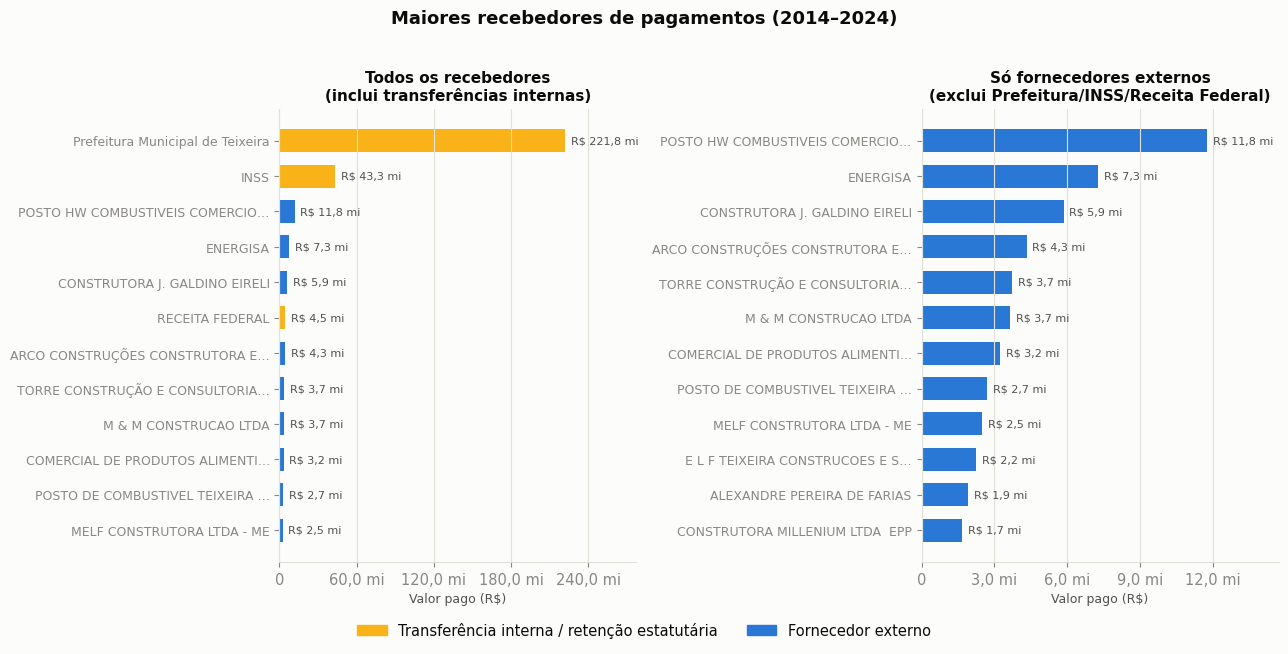

In [12]:
import matplotlib.patches as mpatches

top_geral = df.groupby("Nome")["Valor Pago"].sum().sort_values(ascending=False).head(12).sort_values()
top_externo = (
    df[~df["Nome"].isin(ENTIDADES_INTERNAS)].groupby("Nome")["Valor Pago"].sum()
    .sort_values(ascending=False).head(12).sort_values()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, serie, titulo in [
    (axes[0], top_geral, "Todos os recebedores\n(inclui transferências internas)"),
    (axes[1], top_externo, "Só fornecedores externos\n(exclui Prefeitura/INSS/Receita Federal)"),
]:
    cores = [STATUS["warning"] if nome in ENTIDADES_INTERNAS else CAT_PALETTE["blue"] for nome in serie.index]
    nomes_curtos = [n if len(n) <= 32 else n[:30] + "…" for n in serie.index]
    bars = ax.barh(nomes_curtos, serie.values, color=cores, height=0.65)
    for bar, val in zip(bars, serie.values):
        ax.text(val + serie.max() * 0.02, bar.get_y() + bar.get_height() / 2, fmt_reais(val),
                va="center", fontsize=8, color=INK_SECONDARY)
    ax.xaxis.set_major_formatter(EIXO_VALOR)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=5))
    ax.set_xlim(0, serie.max() * 1.25)
    ax.set_xlabel("Valor pago (R$)", fontsize=9)
    ax.set_title(titulo, fontsize=11)
    ax.grid(axis="y", visible=False)
    ax.tick_params(axis="y", labelsize=9)

legenda = [
    mpatches.Patch(color=STATUS["warning"], label="Transferência interna / retenção estatutária"),
    mpatches.Patch(color=CAT_PALETTE["blue"], label="Fornecedor externo"),
]
fig.legend(handles=legenda, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.05))

fig.suptitle("Maiores recebedores de pagamentos (2014–2024)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 6.2 Curva de concentração (Pareto) dos fornecedores externos

Quanto do gasto está nas mãos de poucos fornecedores? Ordenamos os fornecedores externos do maior para o menor e acumulamos a participação no total pago — a leitura clássica de curva de Lorenz/Pareto, comparada com a diagonal de "distribuição igualitária".

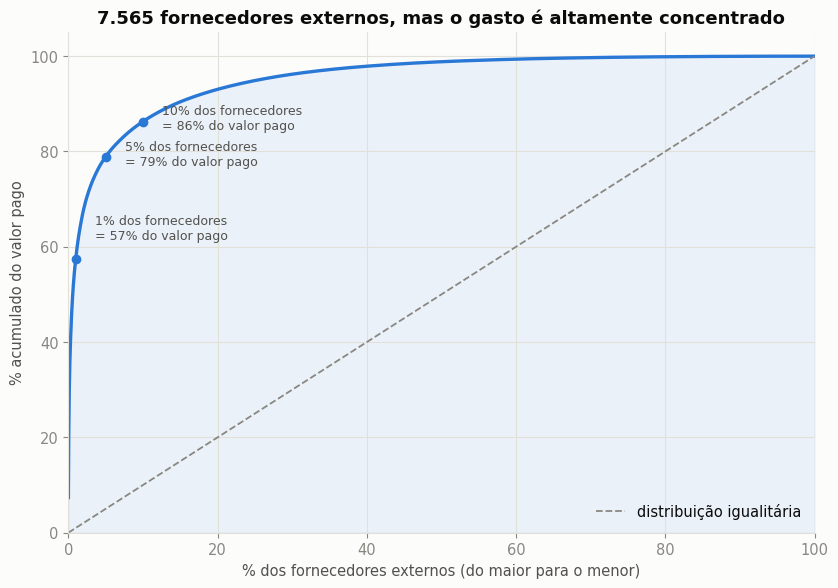

In [13]:
por_fornecedor = (
    df[~df["Nome"].isin(ENTIDADES_INTERNAS)].groupby("Nome")["Valor Pago"].sum()
    .sort_values(ascending=False)
)
n = len(por_fornecedor)
pct_fornecedores = np.arange(1, n + 1) / n * 100
pct_acumulado = por_fornecedor.cumsum().values / por_fornecedor.sum() * 100

fig, ax = plt.subplots(figsize=(8.5, 6))
ax.plot(pct_fornecedores, pct_acumulado, color=CAT_PALETTE["blue"], linewidth=2.4)
ax.plot([0, 100], [0, 100], color=INK_MUTED, linestyle="--", linewidth=1.3, label="distribuição igualitária")
ax.fill_between(pct_fornecedores, pct_acumulado, color=CAT_PALETTE["blue"], alpha=0.08)

for pct in [1, 5, 10]:
    k = max(1, int(n * pct / 100))
    y = pct_acumulado[k - 1]
    ax.plot([pct], [y], "o", color=CAT_PALETTE["blue"], markersize=6)
    ax.annotate(f"{pct}% dos fornecedores\n= {y:.0f}% do valor pago", (pct, y), xytext=(14, -6 if pct > 1 else 14),
                textcoords="offset points", fontsize=9, color=INK_SECONDARY)

n_fmt = f"{n:,}".replace(",", ".")
ax.set_xlabel("% dos fornecedores externos (do maior para o menor)")
ax.set_ylabel("% acumulado do valor pago")
ax.set_xlim(0, 100)
ax.set_ylim(0, 105)
ax.set_title(f"{n_fmt} fornecedores externos, mas o gasto é altamente concentrado")
ax.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

## 7. Execução orçamentária e distribuição dos valores

### 7.1 Quanto do que foi empenhado realmente virou pagamento?

Uma proporção contra uma referência de 100% → barras com linha de base explícita.

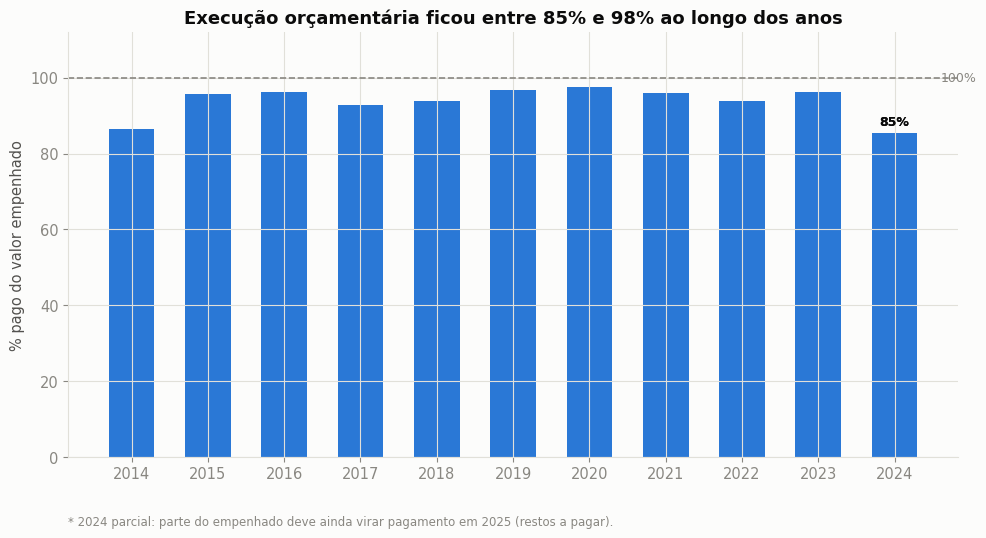

In [14]:
exec_anual = (anual["Valor Pago"] / anual["Valor Empenhado"] * 100)

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.bar(exec_anual.index, exec_anual.values, color=CAT_PALETTE["blue"], width=0.6)
ax.axhline(100, color=INK_MUTED, linestyle="--", linewidth=1.2)
ax.text(exec_anual.index.max() + 0.6, 100, "100%", va="center", fontsize=9, color=INK_MUTED)

for ano_destaque in [exec_anual.idxmin(), 2024]:
    val = exec_anual.loc[ano_destaque]
    ax.annotate(f"{val:.0f}%", (ano_destaque, val), xytext=(0, 6), textcoords="offset points",
                ha="center", fontsize=9, fontweight="bold", color=INK)

ax.set_xticks(exec_anual.index)
ax.set_ylim(0, 112)
ax.set_ylabel("% pago do valor empenhado")
ax.set_title("Execução orçamentária ficou entre 85% e 98% ao longo dos anos")
ax.text(0, -0.16, "* 2024 parcial: parte do empenhado deve ainda virar pagamento em 2025 (restos a pagar).",
        transform=ax.transAxes, fontsize=8.5, color=INK_MUTED)
plt.tight_layout()
plt.show()

### 7.2 Distribuição dos valores por empenho

A maior parte dos empenhos é de baixo valor (auxílios, diárias, pequenas compras), com uma cauda longa de contratos grandes — por isso o eixo de valor em escala logarítmica.

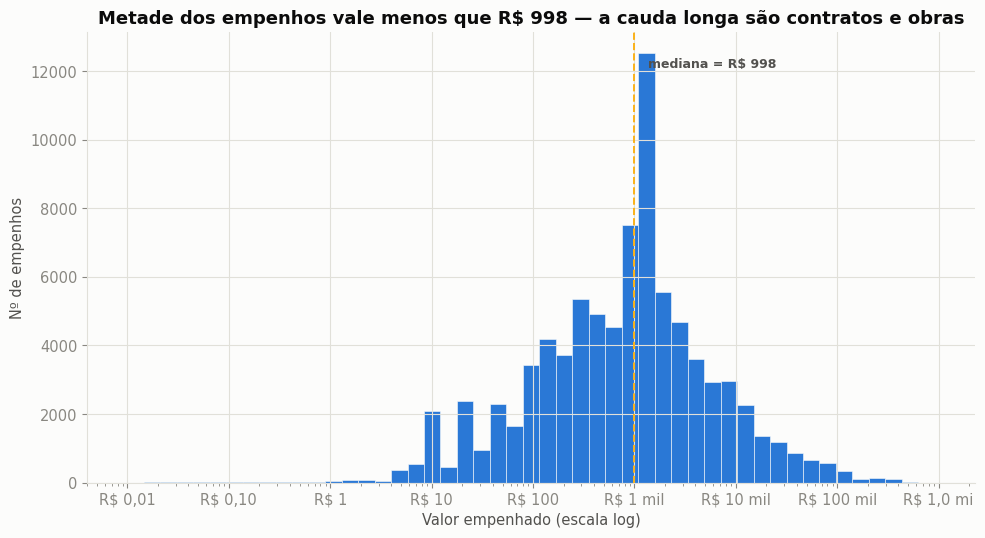

In [15]:
valores_pos = df.loc[df["Valor Empenhado"] > 0, "Valor Empenhado"]
bins = np.logspace(np.log10(valores_pos.min()), np.log10(valores_pos.max()), 50)


def fmt_reais_log(valor, pos=None):
    return f"R$ {valor:.2f}".replace(".", ",") if valor < 1 else fmt_reais(valor)


fig, ax = plt.subplots(figsize=(10, 5.5))
ax.hist(valores_pos, bins=bins, color=CAT_PALETTE["blue"], edgecolor=SURFACE, linewidth=0.4)
ax.set_xscale("log")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_reais_log))

mediana = valores_pos.median()
ax.axvline(mediana, color=STATUS["warning"], linestyle="--", linewidth=1.4)
ax.annotate(f"mediana = {fmt_reais(mediana)}", (mediana, ax.get_ylim()[1] * 0.92), xytext=(10, 0),
            textcoords="offset points", color=INK_SECONDARY, fontsize=9, fontweight="bold")

ax.set_xlabel("Valor empenhado (escala log)")
ax.set_ylabel("Nº de empenhos")
ax.set_title(f"Metade dos empenhos vale menos que {fmt_reais(mediana)} — a cauda longa são contratos e obras")
plt.tight_layout()
plt.show()

## 8. Sinais de possíveis irregularidades

Esta seção levanta **indícios estatísticos**, técnicas usadas em auditoria e ciência de dados forense. Nenhum dos achados abaixo prova irregularidade sozinho — divergências podem ter explicações legítimas (parcelas de contrato, tarifas de concessionária com múltiplas unidades consumidoras, calendário de folha de pagamento). O valor está em **apontar onde vale a pena olhar com mais atenção**.

### 8.1 Lei de Benford no primeiro dígito

**O que é a Lei de Benford?** Em muitos conjuntos de números "naturais" — que cobrem várias ordens de grandeza (dezenas, centenas, milhares...) — o **primeiro dígito** não é uniformemente distribuído. Seria intuitivo esperar que 1, 2, 3... 9 aparecessem cada um ~11% das vezes como primeiro dígito, mas na prática o dígito `1` aparece em ~30% dos casos, o `2` em ~17,6%, caindo até o `9` com só ~4,6%. Isso vale para contas de luz, populações de cidades, valores de notas fiscais etc. — é um fenômeno estatístico real, não um capricho.

Por que isso interessa para auditoria: quando alguém **fabrica ou manipula números "à mão"**, tende a distribuir os dígitos de forma mais uniforme do que a natureza faria. Por isso, grandes desvios da curva de Benford são usados como *sinal de alerta* (não prova) em perícia contábil.

**Como ler o gráfico abaixo:**
- Eixo X = primeiro dígito de cada valor empenhado (ex.: R$ 153,20 → primeiro dígito "1"; R$ 8.400 → primeiro dígito "8").
- Barra azul = o que realmente aconteceu nos dados de Teixeira.
- Linha cinza = o que a Lei de Benford prevê para dados "naturais".
- **O achado**: o dígito `1` aparece em ~37% dos empenhos, acima dos ~30% esperados. Mas isso tem uma explicação bem mais provável que fraude, dado o que já vimos: a prefeitura faz milhares de pagamentos de auxílio social com valores fixos e baixos (R$ 100, R$ 120, R$ 150, R$ 180...) — todos começando com "1", o que infla esse dígito mecanicamente, sem qualquer manipulação.

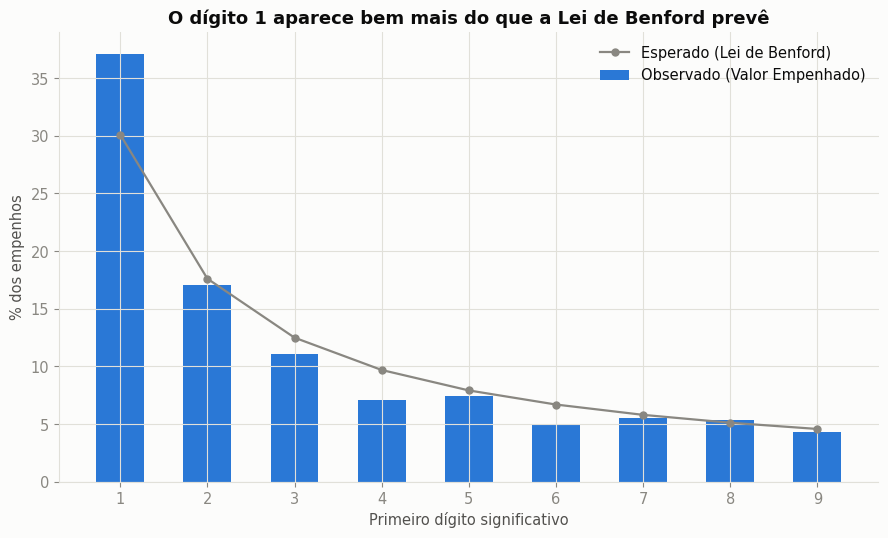

Desvio absoluto total observado-vs-Benford: 14.5 pontos percentuais
Maior desvio individual: 1 dígito


In [16]:
primeiro_digito = valores_pos.astype(str).str.replace(".", "", regex=False).str.lstrip("0").str[0].astype(int)
observado = primeiro_digito.value_counts(normalize=True).sort_index() * 100
benford = pd.Series({d: np.log10(1 + 1 / d) * 100 for d in range(1, 10)})

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(observado.index, observado.values, color=CAT_PALETTE["blue"], width=0.55, label="Observado (Valor Empenhado)")
ax.plot(benford.index, benford.values, color=INK_MUTED, marker="o", markersize=5, linewidth=1.6, label="Esperado (Lei de Benford)")

ax.set_xticks(range(1, 10))
ax.set_xlabel("Primeiro dígito significativo")
ax.set_ylabel("% dos empenhos")
ax.set_title("O dígito 1 aparece bem mais do que a Lei de Benford prevê")
ax.legend(loc="upper right", frameon=False)
plt.tight_layout()
plt.show()

desvio = (observado - benford).abs().sum()
print(f"Desvio absoluto total observado-vs-Benford: {desvio:.1f} pontos percentuais")
print("Maior desvio individual:", (observado - benford).abs().idxmax(), "dígito")

### 8.2 Despesas sem processo licitatório

A coluna `Licitação` marca se o empenho passou por um processo de licitação. É esperado que grande parte do orçamento (folha de pagamento, benefícios, tributos) não passe por licitação — isso não é irregular por si só. O que importa observar é a **tendência**: a fatia sem licitação está caindo ou subindo?

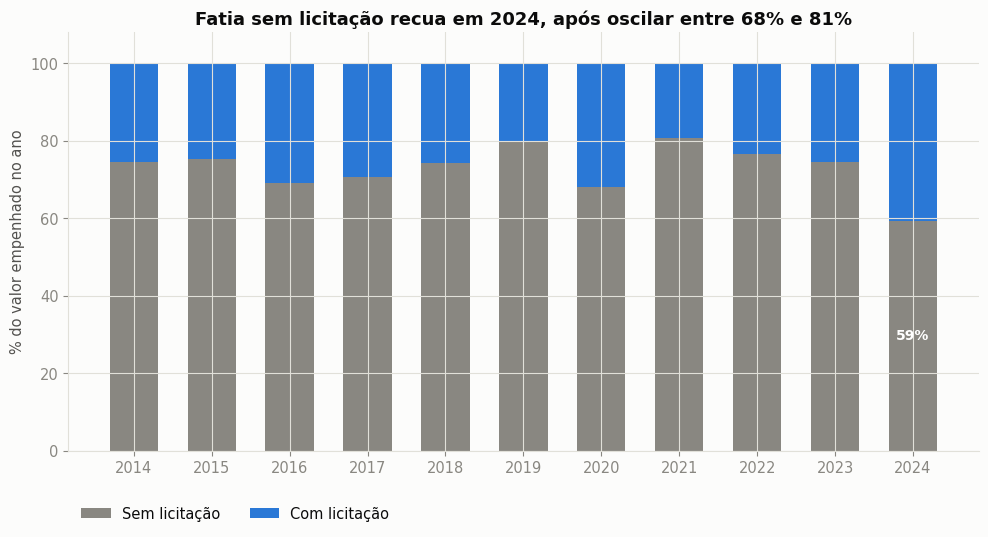

In [17]:
pivot_lic = df.groupby(["ano", "Licitação"])["Valor Empenhado"].sum().unstack(fill_value=0)
pivot_lic_pct = pivot_lic.div(pivot_lic.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5.5))
bottom = np.zeros(len(pivot_lic_pct))
for cor, col, label in [(INK_MUTED, "NÃO", "Sem licitação"), (CAT_PALETTE["blue"], "SIM", "Com licitação")]:
    ax.bar(pivot_lic_pct.index, pivot_lic_pct[col], bottom=bottom, color=cor, width=0.62, label=label)
    bottom += pivot_lic_pct[col].values

ax.annotate(f"{pivot_lic_pct.loc[2024, 'NÃO']:.0f}%", (2024, pivot_lic_pct.loc[2024, 'NÃO'] / 2),
            ha="center", va="center", fontsize=10, fontweight="bold", color="white")

ax.set_xticks(pivot_lic_pct.index)
ax.set_ylim(0, 108)
ax.set_ylabel("% do valor empenhado no ano")
ax.set_title("Fatia sem licitação recua em 2024, após oscilar entre 68% e 81%")
ax.legend(loc="lower left", ncol=2, frameon=False, bbox_to_anchor=(0, -0.2))
plt.tight_layout()
plt.show()

### 8.3 Valores redondos e possível fracionamento de despesas

Dois testes clássicos de auditoria:

- **Valores redondos em excesso** podem indicar estimativas em vez de medições reais (mais comum em benefícios/auxílios, que já sabemos ser boa parte do gasto).
- **Fracionamento**: dividir uma compra grande em vários empenhos pequenos para evitar licitação é uma fraude conhecida no serviço público brasileiro. Um sinal (não uma prova) é o mesmo fornecedor receber **vários empenhos sem licitação no mesmo dia**, em categorias de compra/serviço (não folha de pagamento). Excluímos aqui a Prefeitura/INSS/Receita Federal (transferências internas e retenções, não fornecedores) e elementos de despesa de pessoal.

Empenhos múltiplos de R$ 100: 27.7%
Empenhos múltiplos de R$ 1.000: 4.1%


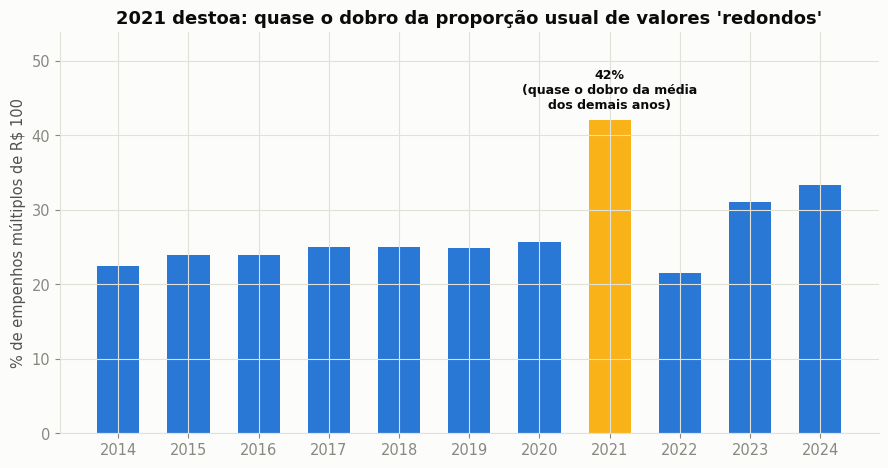

2021: 42.1% dos empenhos são múltiplos de R$ 100, vs. média de 25.7% nos demais anos.


In [18]:
redondo_100 = (valores_pos % 100 == 0).mean() * 100
redondo_1000 = (valores_pos % 1000 == 0).mean() * 100
print(f"Empenhos múltiplos de R$ 100: {redondo_100:.1f}%")
print(f"Empenhos múltiplos de R$ 1.000: {redondo_1000:.1f}%")

por_ano_redondo = df[df["Valor Empenhado"] > 0].groupby("ano").apply(
    lambda g: (g["Valor Empenhado"] % 100 == 0).mean() * 100, include_groups=False
)
ano_pico = por_ano_redondo.idxmax()
cores_redondo = [STATUS["warning"] if a == ano_pico else CAT_PALETTE["blue"] for a in por_ano_redondo.index]

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(por_ano_redondo.index, por_ano_redondo.values, color=cores_redondo, width=0.6)
ax.annotate(f"{por_ano_redondo[ano_pico]:.0f}%\n(quase o dobro da média\ndos demais anos)", (ano_pico, por_ano_redondo[ano_pico]),
            xytext=(0, 8), textcoords="offset points", ha="center", fontsize=9, fontweight="bold", color=INK)
ax.set_xticks(por_ano_redondo.index)
ax.set_ylim(0, por_ano_redondo.max() * 1.28)
ax.set_ylabel("% de empenhos múltiplos de R$ 100")
ax.set_title(f"{ano_pico} destoa: quase o dobro da proporção usual de valores 'redondos'")
plt.tight_layout()
plt.show()

media_outros_anos = por_ano_redondo.drop(ano_pico).mean()
print(f"{ano_pico}: {por_ano_redondo[ano_pico]:.1f}% dos empenhos são múltiplos de R$ 100, "
      f"vs. média de {media_outros_anos:.1f}% nos demais anos.")

In [19]:
ELEMENTOS_COMPRA = {
    "MATERIAL DE CONSUMO",
    "OUTROS SERVIÇOS DE TERCEIROS - PESSOA JURÍDICA",
    "OBRAS E INSTALAÇÕES",
    "EQUIPAMENTOS E MATERIAL PERMANENTE",
    "MATERIAL, BEM OU SERVIÇO PARA DISTRIBUIÇÃO GRATUITA",
    "OUTROS SERVIÇOS DE TERCEIROS - PESSOA FÍSICA",
}

candidatos = df[
    (df["Licitação"] == "NÃO")
    & df["elemento"].isin(ELEMENTOS_COMPRA)
    & ~df["Nome"].isin(ENTIDADES_INTERNAS)
]
watchlist = (
    candidatos.groupby(["Nome", "Data"])
    .agg(n_empenhos=("Valor Empenhado", "size"), total_dia=("Valor Empenhado", "sum"))
    .query("n_empenhos > 2")
    .sort_values("total_dia", ascending=False)
    .head(15)
)
watchlist["total_dia"] = watchlist["total_dia"].map(fmt_reais_full)
watchlist

n_empenhos      total_dia
Nome                                               Data                                 
ENERGISA                                           2020-12-23           6  R$ 232.656,53
                                                   2021-05-18           3  R$ 141.174,99
                                                   2021-11-24           9  R$ 139.485,39
                                                   2021-09-17          12  R$ 121.793,75
                                                   2023-12-29           3  R$ 105.078,86
                                                   2022-04-13          10   R$ 95.985,65
POSTO HW COMBUSTIVEIS COMERCIO LTDA-ME             2023-11-10           5   R$ 88.229,70
ENERGISA                                           2023-06-12           9   R$ 73.798,61
                                                   2022-12-30          13   R$ 72.179,53
NNMED DIST IMP DE MED LTDA                         2017-04-27           6   R$ 70.814,10
ENERGISA                                           2023-02-09           8   R$ 67.011,80
                                                   2022-09-09          11   R$ 66.612,00
A. COSTA COMERCIO ATAC DE PRODUTOS FARMACEUTICO... 2020-12-10           4   R$ 64.975,35
ENERGISA                                           2020-11-23           9   R$ 62.375,59
                                                   2022-05-16           8   R$ 62.046,99

**Como ler esta lista:** ela é um ponto de partida para auditoria manual, não uma acusação. Concessionárias de energia/água tendem a aparecer aqui porque pagam uma conta por unidade consumidora (posto de saúde, escola, praça) no mesmo dia — um padrão legítimo. Já repetições envolvendo construtoras e fornecedores de material em datas muito próximas, sempre pouco abaixo do mesmo valor, merecem checagem do processo administrativo e do objeto contratado.

## 9. Conclusões

**Qualidade dos dados**
- O arquivo bruto tinha ~150 linhas corrompidas por quebras de linha embutidas no campo `Histórico` e duas colunas homônimas (`Data de Liquidação`); ambos os problemas foram tratados de forma auditável nesta seção 2.
- `Órgão` é praticamente uma constante (não segmenta nada); `Unid. Orc`, `Função` e `Elemento` são as dimensões úteis para análise, desde que a caixa do texto seja normalizada e um pequeno resíduo de linhas com `Função` corrompida seja descartado dessa visão específica.

**Evolução do gasto**
- O gasto empenhado saltou de ~R$ 25,5 milhões (2014) para ~R$ 77,3 milhões (2024, ano ainda parcial) — quase triplicou em 11 anos.
- Dezembro é disparado o mês de maior volume, e despesas de capital (obras) tendem a crescer nos anos de eleição municipal (2016, 2020, 2024).

**Composição**
- Educação, Saúde e Administração somam ~75% do gasto por valor. Assistência Social é a função com o 3º maior número de lançamentos (muitos auxílios de baixo valor unitário), mas cai para posições mais baixas quando o critério é valor total — um bom lembrete de que "mais frequente" e "mais caro" são coisas diferentes.
- Folha de pessoal (vencimentos, contratações temporárias, encargos patronais) sozinha responde por mais da metade do orçamento.
- A execução orçamentária (pago/empenhado) ficou entre 85% e 98% ao ano, sem sinal de deterioração.

**Concentração e possíveis pontos de atenção**
- Entre os fornecedores externos (excluindo transferências internas e retenções), 1% deles concentra mais da metade de tudo que foi pago — concentração alta mesmo descontando contas de utilidade pública e obras legítimas.
- O primeiro dígito dos valores empenhados se desvia visivelmente da Lei de Benford, mas isso é parcialmente explicado por valores fixos de benefícios sociais repetidos em massa.
- A fatia de despesas sem licitação recuou de forma notável em 2024 (~59%, ante 68–81% nos anos anteriores).
- **2021 destoa nos valores "redondos"**: quase 42% dos empenhos daquele ano são múltiplos exatos de R$ 100, quase o dobro da média dos demais anos (~24-25%) — um desvio isolado que não se repete nos anos vizinhos e que merece checagem pontual do que mudou naquele ano (mudança de sistema? lote específico de lançamentos?).
- A lista de "mesmo fornecedor + mesmo dia + sem licitação" traz candidatos que merecem checagem manual do processo administrativo — a maioria com explicação plausível (concessionárias com múltiplas unidades consumidoras), mas alguns padrões envolvendo construtoras/fornecedores de material valem investigação adicional.

> Reforçando o aviso do início: estes são **sinais estatísticos para orientar auditoria**, não veredictos. A conclusão sobre qualquer irregularidade depende dos processos administrativos, contratos e justificativas de cada empenho apontado.